# 🛒 Discount Impact Analysis – Eniac Case Study

## 1. Executive Summary

This analysis investigates the impact of discount strategies on sales volume, revenue, and customer behavior for Eniac, an e-commerce company.

A key internal debate exists between marketing and investors regarding whether discounts drive sustainable growth or harm long-term revenue.  
Using historical sales data, this notebook provides data-driven insights to support strategic decision-making.


## 2. Business Context

Eniac frequently applies discounts as part of its marketing strategy. While discounts are believed to increase customer acquisition and order volume, concerns have been raised regarding their impact on overall revenue and brand positioning.

### Stakeholder Perspectives
- Marketing Team: Discounts increase customer engagement and sales.
- Investors: Discounts reduce margins and may attract low-value customers.

## Problem Statement

Do discount strategies lead to sustainable business growth, or do they primarily increase order volume at the cost of revenue?


## 3. Data Overview

The dataset contains historical order-level data including:
- Order quantities
- Discount levels
- Revenue
- Product and customer information
- Time-based attributes

The analysis focuses on comparing discounted and non-discounted sales.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
orders_df = pd.read_csv("../data/raw/orders.csv")
products_df = pd.read_csv("../data/raw/products.csv")
orderlines_df = pd.read_csv("../data/raw/orderlines.csv")

### 3.1 head

In [ ]:
orders_df.head(5)

In [ ]:
orders_df["state"].value_counts(normalize=True)

- Most of the orders are in the shopping basket which are not ordered yet.
- Cancelled and pending orders can be removed from the orders_df.

In [ ]:
products_df.head(5)

In [ ]:
orderlines_df.head(5)

### 3.2 info

In [ ]:
orders_df.info()

In [ ]:
orders_df.isna().sum()

- There is null values in total_paid.
- Transform created_date's type from object to datetime.

In [ ]:
products_df.info()

In [ ]:
products_df.isna().sum()

- There are null values in desc, price and type column.
- Convert the type of the price and promo_price from object to float.

In [ ]:
orderlines_df.info()

In [ ]:
orderlines_df.isna().sum()

- There is not any missing value.
- Convert the type of unit_price from object to float.
- Convert the type of the date from object to datetime.

### 3.3 describe

In [ ]:
orders_df.describe(include="all")

In [ ]:
products_df.describe(include="all")

- There are dublicates in sku. Remove them.

In [ ]:
orderlines_df.describe(include="all")

- All the product_id is 0. It does not mean anything. Drop the column.

## 4. Data Cleaning & Preprocessing

Before analysis, the dataset was cleaned and prepared:
- Missing values were handled
- Incorrect or inconsistent entries were corrected
- Relevant features were selected for analysis
- Date and time features were standardized


### 4.1 Orders

#### 4.1.1 Data Type Conversion

In [ ]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

orders_df["create_year"] = orders_df["created_date"].dt.year
orders_df["create_month"] = orders_df["created_date"].dt.month
orders_df["create_weekday"] = orders_df["created_date"].dt.day_name()

#### 4.1.2 Duplicates

In [ ]:
orders_df.duplicated().sum()

#### 4.1.3 Missing Values

In [ ]:
orders_df['total_paid'].isna().value_counts(normalize=True)


- As there is such a tiny amount of missing values, we will simply delete these rows, as we have enough data without them.

In [ ]:
orders_df = orders_df.dropna(axis=0)

#### 4.1.4 Filtering

In [ ]:
orders_df = orders_df[orders_df["total_paid"] > 0]

### 4.2 Orderlines

#### 4.2.1 Data Type Conversion

In [ ]:
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

orderlines_df["year"] = orderlines_df["date"].dt.year
orderlines_df["month"] = orderlines_df["date"].dt.month
orderlines_df["weekday"] = orderlines_df["date"].dt.day_name()

In [ ]:
orderlines_df["unit_price"] = orderlines_df["unit_price"].astype(float)

As you can see when we try to convert `unit_price` to a numerical datatype, we receive a `ValueError` telling us that pandas doesn't understand the number `1.137.99`. This is probably because numbers cannot have multiple decimal points. Let's see if there are any other numbers like this:

> `.` is a wildcard in regex, we need the `\` as an escape

In [ ]:
orderlines_df['unit_price'].str.count("\.").value_counts(normalize=True)

This is a bit of a tricky decision as 12.3% is a significant amount of our data... and we might even end up losing a larger portion of our data than this too. For the moment we will delete the rows as we only have 2 weeks for this project and I'd like some quick, accurate results to show. If we have time at the end, we can come back and investigate this problem further, maybe there's a solution?

Each row of `orderlines` represents a product in an order. For example, if order number 175 contained 3 seperate products, then order 175 would have 3 rows in `orderlines`, one row for each of the products. If 2 of those products have 'normal' prices (14.99, 15.85) and 1 has a price with 2 decimal points (1.137.99), we need to remove the whole order and not just the affected row. If we only remove the row with 2 decimal places then any later analysis about products and prices could be misleading.

We therefore need to find the order numbers associated with the rows that have 2 decimal points, and then remove all the associated rows.

In [ ]:
# Boolean mask to find the orders that contain a price with multiple decimal points
multiple_decimal_mask = orderlines_df['unit_price'].str.count("\.") > 1

# Apply the boolean mask to the orderlines DataFrame. This way we can find the order_id of all the affected orders.
corrupted_order_ids = orderlines_df.loc[multiple_decimal_mask, "id_order"]

# Keep only the rows that do not have multiple decimal points
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(corrupted_order_ids)]

In [ ]:
orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

#### 4.2.2 Duplicates

In [ ]:
orderlines_df.duplicated().sum()

#### 4.2.3 Missing Values

In [ ]:
orderlines_df.isna().sum()

#### 4.2.4 Filtering

In [ ]:
orderlines_df = orderlines_df[orderlines_df["product_quantity"] > 0]
orderlines_df = orderlines_df[orderlines_df["unit_price"] > 0]

### 4.3 Products

#### 4.3.1 Data Type Conversion

In [ ]:
products_df["price"].str.count("\.").value_counts(normalize=True)

In [ ]:
two_decimal_mask = products_df["price"].str.count(r"\.") > 1
products_df = products_df[~two_decimal_mask]

In [ ]:
products_df["price"].str.count(r"\.").value_counts(normalize=True)

In [ ]:
products_df["price"] = pd.to_numeric(products_df["price"])

In [ ]:
products_df["promo_price"].str.count(r"\.").value_counts(normalize=True)

In [ ]:
products_df = products_df.drop(columns=["promo_price"])

#### 4.3.2 Duplicates

In [ ]:
print("Duplicated product number with default: ", products_df.duplicated().sum())

In [ ]:
products_df.drop_duplicates(inplace=True)

In [ ]:
print("Duplicated product number with default: ", products_df.duplicated().sum())

In [ ]:
print("Duplicated product number with sku: ", products_df.duplicated(subset="sku").sum())

In [ ]:
duplicated_sku = products_df[products_df.duplicated(subset="sku")]

products_df[products_df["sku"].isin(duplicated_sku["sku"])]

In [ ]:
products_df.drop(duplicated_sku.index, axis=0, inplace=True)

In [ ]:
print("Duplicated product number with sku: ", products_df.duplicated(subset="sku").sum())

#### 4.3.3 Missing Values

In [ ]:
nan_desc = products_df["desc"].isna()
products_df.loc[nan_desc, "desc"] = products_df.loc[nan_desc, "name"]

In [ ]:
products_df["desc"].isna().sum()

In [ ]:
products_df["price"].isna().value_counts(normalize=True)

In [ ]:
products_df = products_df.loc[~products_df["price"].isna()]

In [ ]:
products_df["price"].isna().sum()

#### 4.3.4 Filtering

In [ ]:
products_df = products_df[products_df["price"] > 0]

### 4.4 Save cleaned data

In [ ]:
import os
os.makedirs("../data/processed/", exist_ok=True)

orders_df.to_csv("../data/processed/orders_cleaned.csv", index=False)
products_df.to_csv("../data/processed/products_cleaned.csv", index=False)
orderlines_df.to_csv("../data/processed/orderlines_cleaned.csv", index=False)

## 5. Exploratory Data Analysis

Initial exploration was conducted to understand:
- Distribution of discounts
- Order quantities
- Revenue patterns
- Differences between discounted and non-discounted orders


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders_df = pd.read_csv("../data/processed/orders_cleaned.csv")
products_df = pd.read_csv("../data/processed/products_cleaned.csv")
orderlines_df = pd.read_csv("../data/processed/orderlines_cleaned.csv")

### 5.1 Categorize Prices

<Axes: >

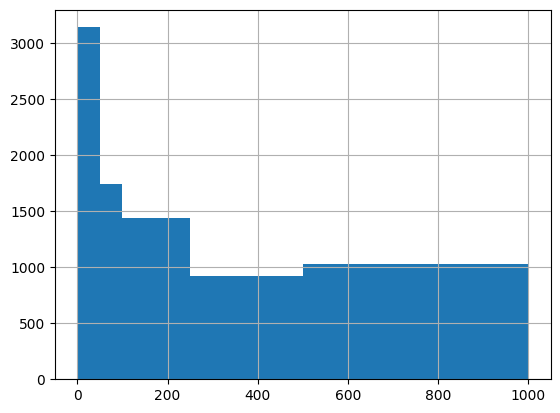

In [4]:
upper_limit = products_df["price"].quantile(0.95)
products_wo_outliers_df = products_df[products_df["price"] <= upper_limit]
products_wo_outliers_df["price"].hist(bins=[0, 50, 100, 250, 500, 1000])

In [5]:
price_ranges = [0, 50, 100, 200, 500]
price_categories = ["1-50", "51-100", "101-200", "201-500", "500+"]
def categorize_by_price(price):
  if price > price_ranges[-1]:
    return str(price_ranges[-1]) + "+"

  for lower, upper in zip(price_ranges[:-1], price_ranges[1:]):
    if lower < price <= upper:
      return str(lower+1) + "-" + str(upper)

<Axes: xlabel='category_by_price'>

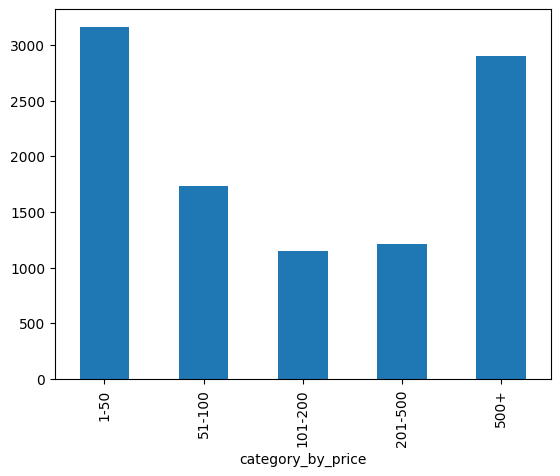

In [6]:
price_category_df = products_df.assign(
    category_by_price = products_df["price"].apply(categorize_by_price)
)
# Print bar plot of price categories_df which is ordered by price_categories
price_category_df["category_by_price"].value_counts().reindex(price_categories).plot(kind="bar")

In [7]:
price_category_df["category_by_price"].value_counts()

category_by_price
1-50       3162
500+       2900
51-100     1729
201-500    1213
101-200    1153
Name: count, dtype: int64

### 5.2 Create Discount Dataframe

In [42]:
discounts_df = orderlines_df.merge(price_category_df, on="sku", how="inner")
discounts_df.drop(["product_id", "in_stock"], axis=1, inplace=True)
discounts_df.sample(1)

,id,id_order,product_quantity,sku,unit_price,date,year,month,weekday,name,desc,price,type,category_by_price
167643,1523810,475749,1,APP1966,351.85,2017-12-29 00:25:41,2017,12,Friday,Apple iPhone 32GB Silver,New iPhone SE with 4-inch screen 32 free GB.,419.0,51601716,201-500


In [43]:
discounts_df = discounts_df.merge(orders_df, left_on="id_order", right_on="order_id", how="inner")
discounts_df = discounts_df[discounts_df["state"] == "Completed"]
discounts_df.sample(1)

,id,id_order,product_quantity,sku,unit_price,date,year,month,weekday,name,...,price,type,category_by_price,order_id,created_date,total_paid,state,create_year,create_month,create_weekday
52573,1240843,352318,1,BEZ0212,24.99,2017-05-03 16:25:57,2017,5,Wednesday,"Be.ez LA robe Case Graphite MacBook Pro 15 ""(L...",...,29.99,13835403,1-50,352318,2017-05-03 16:29:03,54.98,Completed,2017,5,Wednesday


In [44]:
discounts_df.drop(["state", "date", "month", "year", "weekday", "id_order"], axis=1, inplace=True)
discounts_df.sample(1)

,id,product_quantity,sku,unit_price,name,desc,price,type,category_by_price,order_id,created_date,total_paid,create_year,create_month,create_weekday
16003,1160935,1,APP0697,5.99,OEM USB Cable for iPhone iPad Dock and Apple i...,Cable OEM dock for iPhone iPad and iPod compat...,25.0,1230,1-50,315578,2017-01-27 09:57:59,15.97,2017,1,Friday


In [45]:
discounts_df["unit_price_total"] = discounts_df["unit_price"] * discounts_df["product_quantity"]
discounts_df["discount_amount"] = discounts_df["price"] - discounts_df["unit_price_total"]
discounts_df["discount_percentage"] = ((discounts_df["discount_amount"] / discounts_df["price"]) * 100).astype(int)
discounts_df.head(5)

,id,product_quantity,sku,unit_price,name,desc,price,type,category_by_price,order_id,created_date,total_paid,create_year,create_month,create_weekday,unit_price_total,discount_amount,discount_percentage
5,1119116,1,OWC0100,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,12755395,51-100,299545,2017-01-01 01:51:47,51.48,2017,1,Sunday,47.49,13.50,22
6,1119119,1,IOT0014,18.99,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,5720,1-50,299546,2017-01-01 01:57:34,18.99,2017,1,Sunday,18.99,3.96,17
7,1119120,1,APP0700,72.19,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,13005399,51-100,295347,2017-01-01 02:02:38,72.19,2017,1,Sunday,72.19,16.81,18
14,1119134,1,CRU0039-A,60.90,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,1298,51-100,299556,2017-01-01 02:30:08,65.89,2017,1,Sunday,60.90,16.09,20
20,1119145,1,PEB0015,142.49,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,11905404,201-500,299561,2017-01-01 02:39:47,154.48,2017,1,Sunday,142.49,157.50,52


In [46]:
(discounts_df["discount_amount"] >= 0).value_counts()

discount_amount
True     50455
False     5392
Name: count, dtype: int64

- There are some discount which make no sense. Discount should not be smaller than 0. We should remove them from our anlysis.

In [47]:
discounts_df = discounts_df[discounts_df["discount_amount"] >= 0]
discounts_df["discount_amount"].describe()

count    50455.000000
mean        32.412455
std         70.558471
min          0.000000
25%          6.010000
50%         15.960000
75%         34.340000
max       1320.000000
Name: discount_amount, dtype: float64

<Axes: >

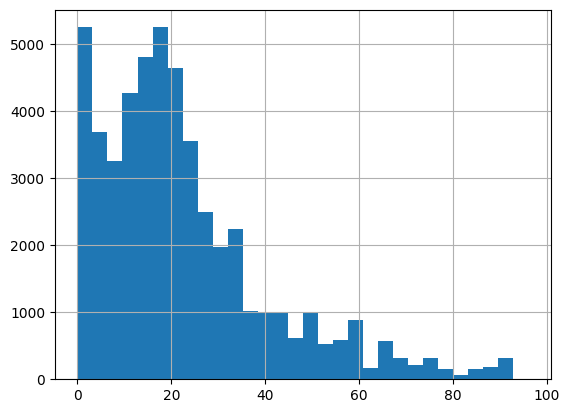

In [48]:
discounts_df["discount_percentage"].hist(bins=30)

In [49]:
discount_range = [0, 5, 10, 20, 30, 50]
discount_categories = ["No Discount", "1-5%", "6-10%", "11-20%", "21-30%", "31-50%", "50%+"]
def categorize_by_discount(discount):
  if discount >= discount_range[-1]:
    return str(discount_range[-1]) + "%+"
  elif discount == 0:
    return "No Discount"

  for lower, upper in zip(discount_range[:-1], discount_range[1:]):
    if lower < discount <= upper:
      return str(lower + 1) + "-" + str(upper) + "%"

<Axes: xlabel='category_by_discount'>

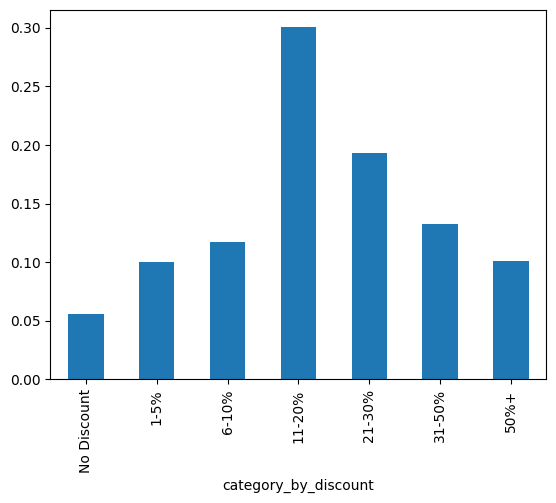

In [50]:
discounts_df["category_by_discount"] = discounts_df["discount_percentage"].apply(categorize_by_discount)
discounts_df["category_by_discount"].value_counts(normalize=True).reindex(discount_categories).plot(kind="bar")

### Revenue: Discounted vs Non-Discounted Orders

<Figure size 1000x600 with 0 Axes>

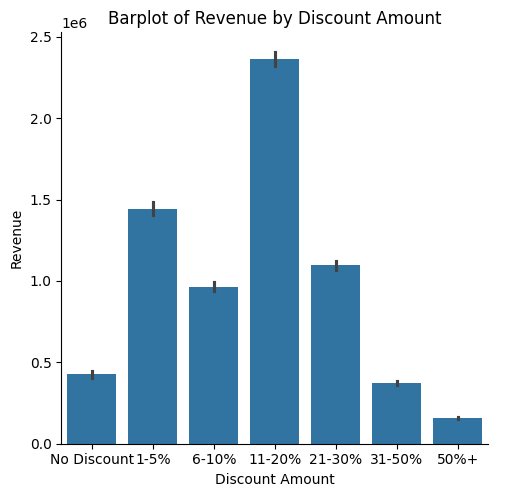

In [61]:
plt.figure(figsize=(10, 6))
sns.catplot(data=discounts_df,
            x="category_by_discount",
            y="unit_price_total",
            estimator="sum",
            kind="bar",
            order=discount_categories
            )
plt.title("Barplot of Revenue by Discount Amount")
plt.xlabel("Discount Amount")
plt.ylabel("Revenue")
plt.show()

### Temporal Patterns

Time-based trends help identify seasonality and behavioral changes over time.

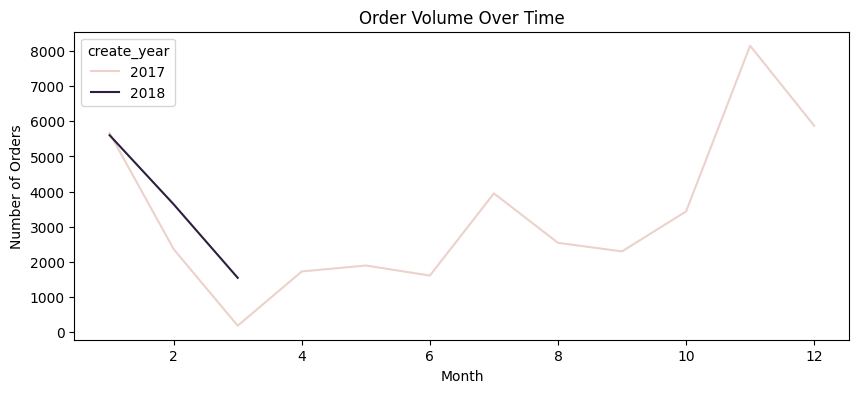

In [65]:
orders_by_month = discounts_df.groupby(["create_year", "create_month"]).size().reset_index(name="orders")

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=orders_by_month,
    x="create_month",
    y="orders",
    hue="create_year"
)
plt.title("Order Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()


## Discount vs Order Quantity

This section analyzes the relationship between discount levels and order quantity to evaluate whether discounts drive higher sales volume.


In [51]:
grouped_discount_df = discounts_df.groupby(["category_by_discount", 
                                            "category_by_price"]).agg(
    quantity_sold = ("product_quantity", "sum"),
    total_revenue = ("unit_price_total", "sum")
).reset_index()

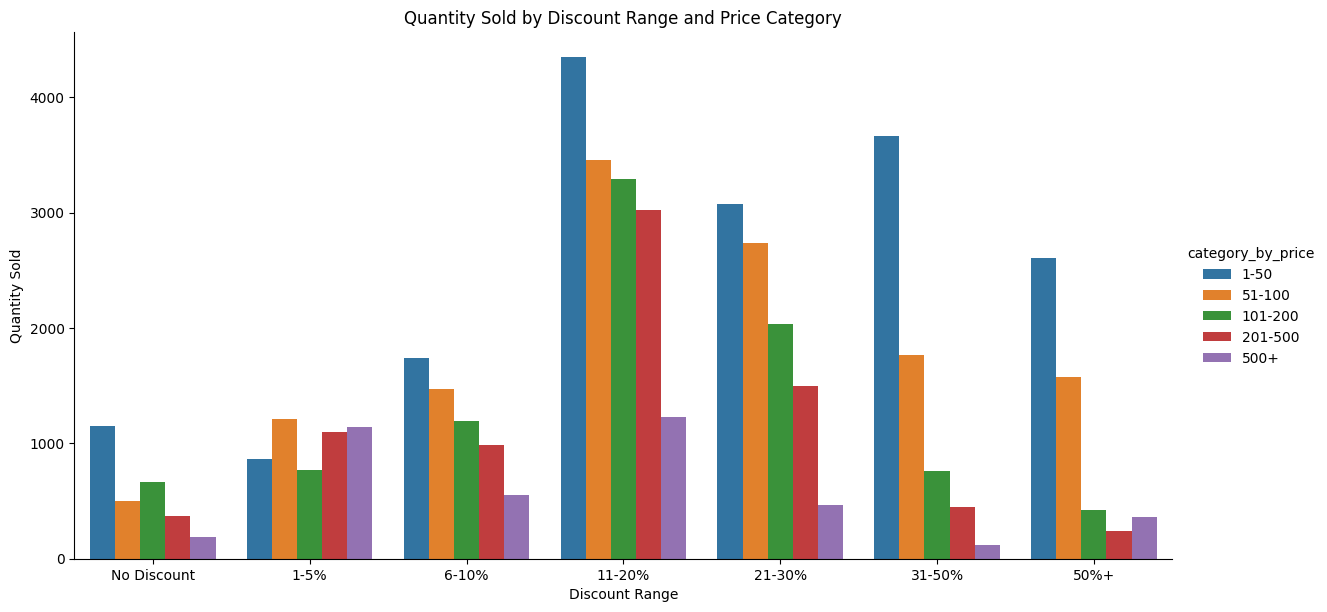

In [52]:
sns.catplot(
    data=grouped_discount_df,
    x="category_by_discount",
    y="quantity_sold",
    hue="category_by_price",
    hue_order=price_categories,
    order=discount_categories,
    kind="bar",
    height=6,
    aspect=2
)
plt.title("Quantity Sold by Discount Range and Price Category")
plt.xlabel("Discount Range")
plt.ylabel("Quantity Sold")
plt.show()

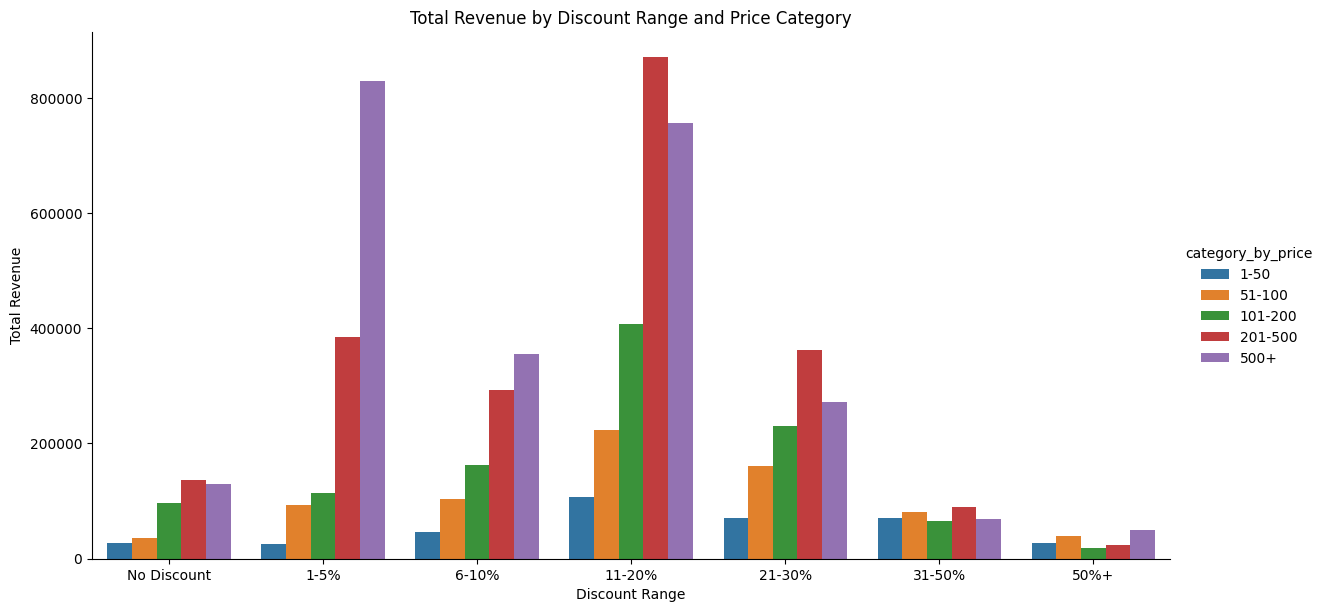

In [53]:
sns.catplot(
    data=grouped_discount_df,
    x="category_by_discount",
    y="total_revenue",
    hue="category_by_price",
    hue_order=price_categories,
    order=discount_categories,
    kind="bar",
    height=6,
    aspect=2
)
plt.title("Total Revenue by Discount Range and Price Category")
plt.xlabel("Discount Range")
plt.ylabel("Total Revenue")
plt.show()

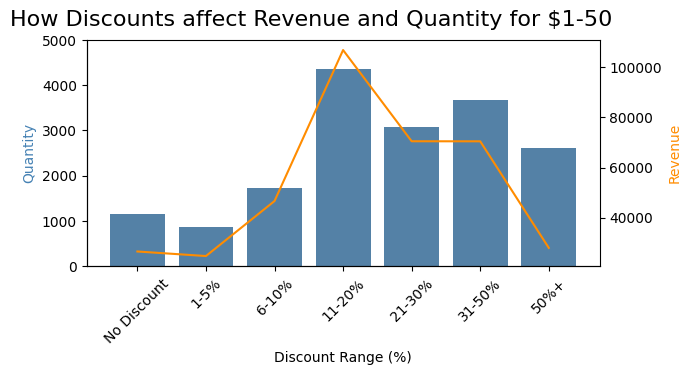

In [54]:
price_between_1_50_df = grouped_discount_df[grouped_discount_df["category_by_price"] == "1-50"]
cat_plot = sns.catplot(data=price_between_1_50_df,
                       x="category_by_discount",
                       y="quantity_sold",
                       kind="bar",
                       order = discount_categories,
                       color="steelblue",
                       height=3,
                       aspect=2,
                       estimator="sum",
                       errorbar=None)

cat_plot.fig.suptitle("How Discounts affect Revenue and Quantity for $1-50", fontsize=16, y=1.05)
cat_plot.ax.set_xlabel("Discount Range (%)")
cat_plot.ax.set_ylabel("Quantity", color="steelblue")
cat_plot.ax.set_ylim(0, 5000)

ax2 = cat_plot.ax.twinx()

sns.lineplot(data=price_between_1_50_df,
             x="category_by_discount",
             y="total_revenue",
             ax=ax2,
             color="darkorange",
             errorbar=None)

ax2.set_ylabel("Revenue", color="darkorange")

for label in cat_plot.ax.get_xticklabels():
  label.set_rotation(45)

cat_plot.fig.subplots_adjust(hspace=0.5, wspace=0.3)
cat_plot.legend.remove()

## Key Findings

- Discounts are effective in increasing order volume, particularly for price-sensitive customers.
- Higher discount levels are associated with lower average revenue per order.
- Increased order quantity does not necessarily translate into proportional revenue growth.
- Discounts attract additional customers, but evidence for long-term retention is mixed.
- The business faces a clear trade-off between short-term sales growth and long-term revenue sustainability.


## Business Recommendations

Based on the analysis:
- Discounts should be applied selectively rather than broadly.
- Discount campaigns should be targeted toward specific customer segments.
- Revenue impact should be monitored alongside order volume.


## Limitations & Next Steps

Limitations:
- Analysis is based on historical data and does not include profit margins.
- Customer lifetime value was not directly calculated.

Next Steps:
- Incorporate profit and margin data
- Perform cohort-based retention analysis
- Build predictive models for discount optimization


## Conclusion

This project demonstrates how data analysis can support strategic decision-making by resolving stakeholder disagreements through evidence-based insights.
